In [1]:
import cv2
import torch
import distinctipy
import matplotlib.pyplot as plt
import numpy as np
from skimage.measure import label, regionprops
import os
import open3d as o3d
from filterpy.kalman import KalmanFilter
from scipy.optimize import linear_sum_assignment
from scipy.spatial import cKDTree
from scipy.spatial.transform import Rotation
from scipy.spatial.transform import Slerp
from sklearn.decomposition import PCA
import numpy as np
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor
from PIL import Image

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
from huggingface_hub import login
hf_token = ''
with open('hf_token.txt', 'r') as token_file:
    hf_token = token_file.read()
login(hf_token)

In [3]:
model = build_sam3_image_model()
processor = Sam3Processor(model,resolution=1008)

In [4]:
def cv2pil(cv_image: np.ndarray) -> Image.Image:
    """
    Converts cv2 BGR image to PIL RGB image
    """
    rgb_image = cv2.cvtColor(cv_image, cv2.COLOR_BGR2RGB)
    return Image.fromarray(rgb_image)

In [5]:
frame_embeds = []

In [6]:
def make_point_cloud(depth_map,conf,intrinsics,extrinsics):
    h, w = depth_map.shape
    fx, fy, cx, cy = intrinsics[0, 0], intrinsics[1, 1], intrinsics[0, 2], intrinsics[1, 2]
    #camera coords
    u, v = np.meshgrid(np.arange(w), np.arange(h))
    x = (u - cx) * depth_map / fx
    y = (v - cy) * depth_map / fy
    z = depth_map
    pts_cam = np.stack([x.flatten(), y.flatten(), z.flatten()], axis=1)
    #world coords
    R = extrinsics[:3,:3]
    t = extrinsics[:3,3]
    pts_world = (R.T @ (pts_cam -t).T).T # (N, 3)
    mask1 = (conf>0.1).flatten()
    _, mask2 = statistical_outlier_removal(pts_world)
    return pts_world[mask1*mask2],mask1*mask2

def statistical_outlier_removal(
    points: np.ndarray,
    k: int = 10,
    std_ratio: float = 1.5
) -> np.ndarray:
    """
    Удаляет точки, чьё среднее расстояние до k ближайших соседей
    превышает (среднее + std_ratio * std) по всему облаку.
    
    Args:
        points: [N, 3] — облако точек
        k: число соседей для анализа (рекомендуется 8–15)
        std_ratio: порог в сигмах (1.0–2.0)
    
    Returns:
        Очищенное облако [M, 3], M <= N
    """
    if len(points) < k + 1:
        return points, np.ones(len(points)).astype(bool)
    
    # Строим KD-дерево для быстрого поиска соседей
    tree = cKDTree(points)
    distances, _ = tree.query(points, k=k+1)  # +1 потому что точка сама себе сосед
    
    # Среднее расстояние до k ближайших (исключая саму точку)
    mean_distances = np.mean(distances[:, 1:], axis=1)
    
    # Глобальные статистики
    global_mean = np.mean(mean_distances)
    global_std = np.std(mean_distances)
    
    # Маска: оставить точки с расстоянием < порога
    mask = mean_distances < (global_mean + std_ratio * global_std)
    return points[mask],mask
    
def create_pcd(image,pts_world,mask):
    colors = image.reshape(-1,3).astype(np.float32)/255
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts_world)
    pcd.colors = o3d.utility.Vector3dVector(colors[mask])
    return pcd

In [7]:
def depth_to_point_cloud_vectorized(depth, intrinsics, extrinsics, device=None):
    """
    depth: [N, H, W] numpy array or torch tensor
    intrinsics: [N, 3, 3] numpy array or torch tensor
    extrinsics: [N, 3, 4] (w2c) numpy array or torch tensor
    Returns: point_cloud_world: [N, H, W, 3] same type as input
    """
    input_is_numpy = False
    if isinstance(depth, np.ndarray):
        input_is_numpy = True

        depth_tensor = torch.tensor(depth, dtype=torch.float32)
        intrinsics_tensor = torch.tensor(intrinsics, dtype=torch.float32)
        extrinsics_tensor = torch.tensor(extrinsics, dtype=torch.float32)

        if device is not None:
            depth_tensor = depth_tensor.to(device)
            intrinsics_tensor = intrinsics_tensor.to(device)
            extrinsics_tensor = extrinsics_tensor.to(device)
    else:
        depth_tensor = depth
        intrinsics_tensor = intrinsics
        extrinsics_tensor = extrinsics

    if device is not None:
        depth_tensor = depth_tensor.to(device)
        intrinsics_tensor = intrinsics_tensor.to(device)
        extrinsics_tensor = extrinsics_tensor.to(device)

    # main logic

    N, H, W = depth_tensor.shape

    device = depth_tensor.device

    u = torch.arange(W, device=device).float().view(1, 1, W, 1).expand(N, H, W, 1)
    v = torch.arange(H, device=device).float().view(1, H, 1, 1).expand(N, H, W, 1)
    ones = torch.ones((N, H, W, 1), device=device)
    pixel_coords = torch.cat([u, v, ones], dim=-1)

    intrinsics_inv = torch.inverse(intrinsics_tensor)  # [N, 3, 3]
    camera_coords = torch.einsum("nij,nhwj->nhwi", intrinsics_inv, pixel_coords)
    camera_coords = camera_coords * depth_tensor.unsqueeze(-1)
    camera_coords_homo = torch.cat([camera_coords, ones], dim=-1)

    extrinsics_4x4 = torch.zeros(N, 4, 4, device=device)
    extrinsics_4x4[:, :3, :4] = extrinsics_tensor
    extrinsics_4x4[:, 3, 3] = 1.0

    c2w = torch.inverse(extrinsics_4x4)
    world_coords_homo = torch.einsum("nij,nhwj->nhwi", c2w, camera_coords_homo)
    point_cloud_world = world_coords_homo[..., :3]

    if input_is_numpy:
        point_cloud_world = point_cloud_world.cpu().numpy()

    return point_cloud_world

In [ ]:
file_dir_name = '2'
frame_path = '../data/%s/' %(file_dir_name)
frame_names = sorted(os.listdir(frame_path))

In [9]:
images = []
image_paths = []
for name in frame_names:
    images.append(cv2.imread('%s/%s' %(frame_path,name)))
    image_paths.append('%s/%s' %(frame_path,name))

In [10]:
frame_embeds = []

In [11]:
for i in range(len(images)):
    image = cv2pil(images[i])
    inference_state = processor.set_image(image)
    frame_embed = inference_state['backbone_out']['vision_features']
    frame_embeds.append(frame_embed[0].reshape((256,-1)).T)

In [ ]:
res_dir = 'da3_outputs/outputs/%s/' %(file_dir_name)
depth_dir = res_dir+'/results_output/'

In [ ]:
extrinsics = []
with open(res_dir+'camera_poses.txt','r') as f:
    all_poses = f.read().split('\n')
for i in range(len(images)):
    pose = all_poses[i]
    pose_np = np.array(pose.split(' ')).astype(float).reshape((4,4))
    extrinsics.append(pose_np)

In [15]:
intrinsics = []
points_per_frame = []
points_per_frame_masks = []
for i in range(len(images)):
    print(i)
    data = np.load(depth_dir+'frame_%d.npz' %(i))
    image = data["image"]  # [H, W, 3] uint8
    depth = data["depth"]  # [H, W] float32
    conf = data["conf"]  # [H, W] float32
    intrinsics = data["intrinsics"]  # [3, 3] float32
    conf_thresh = conf.mean()*0.5 
    depth_reshaped = depth[np.newaxis, :, :]  # [1, H, W]
    intrinsics_reshaped = intrinsics[np.newaxis, :, :]  # [1, 3, 3]
    c2w = extrinsics[i]
    w2c = np.linalg.inv(c2w)
    extrinsics_ = w2c[:3, :]  # [3, 4]
    extrinsics_reshaped = extrinsics_[np.newaxis, :, :]  # [1, 3, 4]

    points_world = depth_to_point_cloud_vectorized(
    depth_reshaped, intrinsics_reshaped, extrinsics_reshaped
    )
    points_world = points_world.reshape(-1, 3).astype(np.float32, copy=False)
    points, points_mask = statistical_outlier_removal(points_world)
    points_mask2 = conf>conf_thresh
    mask = points_mask*points_mask2.flatten()
    points_per_frame.append(points_world[mask])
    points_per_frame_masks.append(mask)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270


In [16]:
h,w = depth.shape

In [17]:
def adaptive_erode_mask_area(mask: np.ndarray, target_area_ratio: float = 0.85) -> np.ndarray:
    """
    Эродирует маску до достижения целевой доли исходной площади.
    Гарантирует, что не уберём слишком много.
    
    Args:
        mask: бинарная маска [H, W]
        target_area_ratio: доля площади после эрозии (0.85 = оставить 85% пикселей)
    """
    if mask.max() <= 1.0:
        mask = (mask * 255).astype(np.uint8)
    
    original_area = cv2.countNonZero(mask)
    if original_area == 0:
        return mask
    
    # Начинаем с минимальной эрозии
    kernel_size = 3
    while kernel_size <= 7:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
        eroded = cv2.erode(mask, kernel, iterations=1)
        current_area = cv2.countNonZero(eroded)
        
        if current_area / original_area >= target_area_ratio:
            return eroded
        
        kernel_size += 2  # увеличиваем ядро на 2 (3 → 5 → 7)
    
    # Если даже при kernel_size=7 площадь упала ниже порога — возвращаем минимальную эрозию
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    return cv2.erode(mask, kernel, iterations=1)

def safe_erode(mask, min_area_after=32):
    original_area = cv2.countNonZero(mask)
    if original_area < min_area_after * 2:  # слишком мелкий объект
        return mask  # пропускаем эрозию
    
    eroded = adaptive_erode_mask_area(mask)
    if cv2.countNonZero(eroded) < min_area_after:
        return mask  # откатываем, если маска стала слишком маленькой
    
    return eroded

In [18]:
def get_obj_point_cloud(image,points,clean_mask,mask,h= 378,w =504):
    image_r = cv2.resize(image,(w,h)).reshape((-1,3))
    H,W = mask.shape
    mask_r = cv2.resize(mask.astype(np.uint8),(w,h))
    eroded_mask = safe_erode(mask_r)
    mask_r = eroded_mask.flatten()[clean_mask]
    pts_mask = points[mask_r>0]
    #pts_mask = dbscan_filter(pts_mask)
    #pts_mask = density_based_filter(pts_mask)
    pts_last, last_mask = statistical_outlier_removal(pts_mask)
    indices = np.indices((h,w))
    ys = (indices[0]*H/h).astype(int)
    xs = (indices[1]*W/w).astype(int)
    pcd = o3d.geometry.PointCloud()
    xs_masked = xs.flatten()[clean_mask][mask_r>0]
    ys_masked = ys.flatten()[clean_mask][mask_r>0]
    if len(pts_last)==0 or len(xs_masked)==0:
        return pcd,[],[]
    pcd.points = o3d.utility.Vector3dVector(pts_last)
    xs_last = xs_masked[last_mask]
    ys_last = ys_masked[last_mask]
    colors = (image_r[clean_mask][mask_r>0][last_mask])
    pcd.colors = o3d.utility.Vector3dVector(colors)
    return pcd,xs_last,ys_last

In [19]:
indices = np.indices((h,w))

In [20]:
images[0].reshape((-1,3)).T.shape

(3, 307200)

In [21]:
ys = indices[0]
xs = indices[1]

In [22]:
ys

array([[  0,   0,   0, ...,   0,   0,   0],
       [  1,   1,   1, ...,   1,   1,   1],
       [  2,   2,   2, ...,   2,   2,   2],
       ...,
       [375, 375, 375, ..., 375, 375, 375],
       [376, 376, 376, ..., 376, 376, 376],
       [377, 377, 377, ..., 377, 377, 377]])

In [23]:
def adaptive_sigma(points_track, points_det, scale_factor=0.2):
    """Вычисляет адаптивную сигму под размер объекта"""
    if len(points_track) == 0 or len(points_det) == 0:
        return 0.1
    
    # Размеры объектов
    size_t = points_track.max(axis=0) - points_track.min(axis=0)
    size_d = points_det.max(axis=0) - points_det.min(axis=0)
    
    # Диагонали
    diag_t = np.linalg.norm(size_t)
    diag_d = np.linalg.norm(size_d)
    avg_diag = (diag_t + diag_d) / 2.0
    
    # σ = scale_factor × размер объекта
    sigma = avg_diag * scale_factor
    
    # Ограничения
    sigma = np.clip(sigma, 0.01, 0.15)
    
    return sigma

In [24]:
def compute_bidirectional_gaussian_ioa(pcd_track, pcd_det, voxel_size=0.01, sigma=0.1):
    """
    Двунаправленный Gaussian-IoA: усредняет IoA(track→det) и IoA(det→track).
    
    Защищает от асимметрии плотности точек.
    """
    # 1. Вокселизируем детекцию
    pcd_det_voxelized = pcd_det.voxel_down_sample(voxel_size)
    
    points_t = np.asarray(pcd_track.points)
    points_d = np.asarray(pcd_det_voxelized.points)
    
    if len(points_t) == 0 or len(points_d) == 0:
        return 0.0
    
    sigma = adaptive_sigma(points_t, points_d)
    
    # 2. Расстояния в обоих направлениях
    dist_t_to_d = np.array(pcd_track.compute_point_cloud_distance(pcd_det_voxelized))
    dist_d_to_t = np.array(pcd_det_voxelized.compute_point_cloud_distance(pcd_track))
    
    # 3. Гауссиана
    match_t_to_d = np.exp(-dist_t_to_d**2 / (2 * sigma**2))
    match_d_to_t = np.exp(-dist_d_to_t**2 / (2 * sigma**2))
    
    # 4. IoA относительно ТРЕКА (какая доля трека покрыта детекцией)
    intersection_from_t = np.sum(match_t_to_d)
    area_t = len(points_t)
    ioa_from_t = intersection_from_t / max(area_t, 1e-6)
    
    # 5. IoA относительно ДЕТЕКЦИИ (какая доля детекции покрыта треком)
    intersection_from_d = np.sum(match_d_to_t)
    area_d = len(points_d)
    ioa_from_d = intersection_from_d / max(area_d, 1e-6)
    
    # 6. Усредняем (защита от асимметрии)
    ioa_bidirectional = (ioa_from_t + ioa_from_d) / 2.0
    
    return ioa_from_t, ioa_from_d, np.clip(ioa_bidirectional, 0.0, 1.0)

In [25]:
def compute_metrics(pcd_track, pcd_det, sigma=0.1):
    points_t = np.asarray(pcd_track.points)
    points_d = np.asarray(pcd_det.points)
    sigma = adaptive_sigma(points_t,points_d)
    # Расстояние от каждой точки Track до ближайшей в Detection
    dist_t_to_d = pcd_track.compute_point_cloud_distance(pcd_det)
    # Расстояние от каждой точки Detection до ближайшей в Track
    dist_d_to_t = pcd_det.compute_point_cloud_distance(pcd_track)
    
    # Мягкое сопоставление через гауссиану
    match_t_to_d = np.exp(-np.array(dist_t_to_d)**2 / (2 * sigma**2))
    match_d_to_t = np.exp(-np.array(dist_d_to_t)**2 / (2 * sigma**2))
    
    # Нормализуем
    similarity_t_to_d = np.mean(match_t_to_d)
    similarity_d_to_t = np.mean(match_d_to_t)
    
    # Симметричное сходство
    ioa_fromt, ioa_fromd, similarity = compute_bidirectional_gaussian_ioa(pcd_track,pcd_det)
    # --- 2. Расчет Chamfer Distance --    
    # Chamfer Distance — это среднее этих расстояний
    chamfer_dist = (np.mean(dist_t_to_d) + np.mean(dist_d_to_t)) / 2
    track_center = pcd_track.get_center()
    det_center = pcd_det.get_center()
    mean_dist=np.linalg.norm(np.mean(points_t,axis=0)-np.mean(points_d,axis=0))
    xmin1,ymin1,zmin1 = np.min(points_t,axis=0)
    xmax1,ymax1,zmax1 = np.max(points_t,axis=0)
    xmin2,ymin2,zmin2 = np.min(points_d,axis=0)
    xmax2,ymax2,zmax2 = np.max(points_d,axis=0)
    size = np.linalg.norm([max(xmax1,xmax2)-min(xmin1,xmin2),max(ymax1,ymax2)-min(ymin1,ymin2),max(zmax1,zmax2)-min(zmin1,zmin2)])
    return similarity,mean_dist,size

In [ ]:
tracks_dir = 'tracks/%s/' %(file_dir_name)
track_files = sorted(os.listdir(tracks_dir))

In [27]:
tracks = {}
for i in range(len(track_files)):
    track = np.load('%s/%d.npz' %(tracks_dir,i),allow_pickle=True)['arr_0']
    if track.tolist()['cls']!=0:
        tracks[i]= track.tolist()

In [28]:
def get_object_embedding(features,mask):
    resized = cv2.resize(mask.astype(np.uint8),(72,72)).reshape(-1,1)
    emb = np.sum(features.cpu().numpy()*resized,axis=0)/(np.sum(resized)+1e-8)
    norm = np.linalg.norm(emb)
    return emb/(norm+1e-8)

In [29]:
class VoxelMap:
    def __init__(self, voxel_size=0.01, alpha=0.3, max_age=300):
        self.voxel_size = voxel_size
        self.alpha = alpha     # Вес новой точки (EMA)
        self.max_age = max_age # Сколько кадров живет воксель без подтверждения
        
        # Структура: { (ix, iy, iz): [ [x, y, z], age ] }
        self.voxels = {}
        self.current_frame = -1

    def add_points(self, points):
        
        self.current_frame += 1
        if len(points) == 0:
            self._expire()
            return
        #ICP
        # 1. Считаем индексы вокселей
        indices = np.floor(points / self.voxel_size).astype(int)
        
        for i, idx in enumerate(indices):
            idx_tuple = tuple(idx)
            new_pt = points[i]
            
            if idx_tuple in self.voxels:
                # Обновляем координаты (EMA) и сбрасываем возраст
                current_data = self.voxels[idx_tuple]
                updated_pt = (1 - self.alpha) * current_data[0] + self.alpha * new_pt
                self.voxels[idx_tuple] = [updated_pt, self.current_frame]
            else:
                # Создаем новый воксель
                self.voxels[idx_tuple] = [new_pt, self.current_frame]
        
        # 2. Удаляем старые воксели
        self._expire()

    def _expire(self):
        """ Удаляет воксели, которые не обновлялись дольше max_age кадров """
        expired_keys = [
            k for k, v in self.voxels.items() 
            if (self.current_frame - v[1]) > self.max_age
        ]
        for k in expired_keys:
            del self.voxels[k]

    def get_pcd(self):
        """ Возвращает PointCloud из актуальных вокселей """
        if not self.voxels:
            return o3d.geometry.PointCloud()
        
        points, _ = statistical_outlier_removal(np.array([v[0] for v in self.voxels.values()]))
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(points)
        return pcd


def gettransform(points):
    """
    Поворачивает облако точек так, чтобы главные компоненты совпадали с осями координат.
    
    Аргументы:
        points: numpy массив формы (N, 3) — облако точек.
    
    Возвращает:
        rotated_points: повернутое облако точек.
        components: матрица главных компонент (3, 3).
    """
    # Центрирование данных
    centroid = np.mean(points, axis=0)
    centered = points - centroid
    
    # Применение PCA
    pca = PCA(n_components=3)
    pca.fit(centered)
    
    # Матрица поворота — это компоненты PCA (собственные векторы)
    rotation_matrix = pca.components_  # (3, 3
    
    return centroid, ensure_right_handed_rotation(rotation_matrix)

def local2global(points,center,rotation):
    rotated = points@rotation
    shifted = rotated+center
    return shifted

def global2local(points,center,rotation):
    centered = points-center
    rotated = centered@rotation.T
    return rotated

def ensure_right_handed_rotation(R):
    """
    Гарантирует, что матрица вращения правоориентирована (правосторонняя).
    
    Аргументы:
        R: [3, 3] - матрица вращения
    
    Возвращает:
        R_right: [3, 3] - правоориентированная матрица вращения
    """
    det = np.linalg.det(R)
    
    # Если определитель отрицательный — левосторонняя система
    if det < 0:
        # Меняем знак последнего столбца (или любой другой)
        R[:, 2] = -R[:, 2]
    
    # Проверяем, что теперь определитель положительный
    assert np.abs(np.linalg.det(R) - 1.0) < 1e-6, "Матрица не является вращением!"
    
    return R    

In [30]:
class AdaptiveQuaternionFilter:
    """
    Адаптивный фильтр кватернионов через взвешенный усреднённый.
    
    Использует:
    - Адаптивный вес в зависимости от угловой скорости
    - Формат кватерниона [x, y, z, w]
    - Защиту от инверсии знака
    """
    def __init__(
        self,
        base_alpha=0.85,    # базовый вес для сглаживания
        min_alpha=0.5,      # минимальный вес (быстрое вращение)
        max_alpha=0.95,     # максимальный вес (медленное вращение)
        velocity_threshold=0.5  # порог угловой скорости
    ):
        self.base_alpha = base_alpha
        self.min_alpha = min_alpha
        self.max_alpha = max_alpha
        self.velocity_threshold = velocity_threshold
        
        # Текущий кватернион [x, y, z, w]
        self.current_quat = np.array([0.0, 0.0, 0.0, 1.0])
        
        # История для вычисления угловой скорости
        self.quat_history = []
        self.time_history = []
        self.max_history = 5
        
        # Угловая скорость
        self.angular_velocity = np.zeros(3)
    
    def update(self, new_quat, current_time=0):
        """
        Обновляет фильтр с новым измерением.
        
        Аргументы:
            new_quat: [x, y, z, w] - новый измеренный кватернион
            current_time: время измерения (для вычисления угловой скорости)
        
        Возвращает:
            отфильтрованный кватернион [x, y, z, w]
        """
        # Нормализуем входной кватернион
        new_quat = new_quat / (np.linalg.norm(new_quat) + 1e-8)
        
        # Защита от инверсииhttps://github.com/AriadneDark/ITL_LRC_VQA/blob/main/scene_description_vlm.md знака
        if np.dot(self.current_quat, new_quat) < 0:
            new_quat = -new_quat
        
        # Вычисляем угловую скорость
        if len(self.quat_history) >= 2:
            # Берём последние два кватерниона
            q1 = self.quat_history[-2]
            q2 = self.quat_history[-1]
            
            # Вычисляем дельту вращения
            r1 = Rotation.from_quat(q1)  # [x, y, z, w]
            r2 = Rotation.from_quat(q2)
            delta_rot = r2 * r1.inv()
            
            # Угловая скорость
            dt = self.time_history[-1] - self.time_history[-2]
            if dt > 1e-6:
                self.angular_velocity = delta_rot.as_rotvec() / dt
        
        # Адаптивный вес в зависимости от угловой скорости
        angular_speed = np.linalg.norm(self.angular_velocity)
        
        if angular_speed > self.velocity_threshold:
            # Быстрое вращение → меньше сглаживания
            alpha = self.min_alpha
        elif angular_speed < 0.1:
            # Медленное вращение → больше сглаживания
            alpha = self.max_alpha
        else:
            # Линейная интерполяция между минимумом и максимумом
            alpha = np.interp(
                angular_speed,
                [0.1, self.velocity_threshold],
                [self.max_alpha, self.min_alpha]
            )
        
        # Взвешенное усреднённое через
        smoothed_quat = self._slerp(self.current_quat, new_quat, t=1-alpha)
        
        # Обновляем текущее состояние
        self.current_quat = smoothed_quat.copy()
        
        # Обновляем историю
        self.quat_history.append(new_quat.copy())
        self.time_history.append(current_time)
        
        if len(self.quat_history) > self.max_history:
            self.quat_history.pop(0)
            self.time_history.pop(0)
        
        return self.current_quat.copy()
    
    def predict(self, dt=1.0):
        """
        Предсказывает кватернион на следующий кадр через угловую скорость.
        
        Аргументы:
            dt: временной шаг
        
        Возвращает:
            предсказанный кватернион [x, y, z, w]
        """
        if np.linalg.norm(self.angular_velocity) < 1e-6:
            # Нет вращения
            return self.current_quat.copy()
        
        # Интегрируем угловую скорость
        angle = np.linalg.norm(self.angular_velocity) * dt
        axis = self.angular_velocity / np.linalg.norm(self.angular_velocity)
        
        # Дельта кватернион
        delta_quat = np.array([
            axis[0] * np.sin(angle / 2),
            axis[1] * np.sin(angle / 2),
            axis[2] * np.sin(angle / 2),
            np.cos(angle / 2)
        ])
        
        # Применяем поворот
        q_current = Rotation.from_quat(self.current_quat)
        q_delta = Rotation.from_quat(delta_quat)
        q_predicted = q_delta * q_current
        
        return np.array([q_predicted.x, q_predicted.y, q_predicted.z, q_predicted.w])
    
    def _slerp(self, q1, q2, t):
        """
        Сферическая интерполяция между двумя кватернионами.
        
        Аргументы:
            q1, q2: [x, y, z, w] - кватернионы
            t: параметр интерполяции [0, 1]
        
        Возвращает:
            интерполированный кватернион [x, y, z, w]
        """
        # Нормализуем
        q1 = q1 / (np.linalg.norm(q1) + 1e-8)
        q2 = q2 / (np.linalg.norm(q2) + 1e-8)
        
        # Защита от инверсии
        if np.dot(q1, q2) < 0:
            q2 = -q2
        
        # Если кватернионы почти идентичны — линейная интерполяция
        dot = np.dot(q1, q2)
        if dot > 0.9995:
            result = q1 + t * (q2 - q1)
            return result / (np.linalg.norm(result) + 1e-8)
        
        # Вычисляем угол между кватернионами
        theta_0 = np.arccos(dot)
        theta = theta_0 * t
        
        # Синусы углов
        sin_theta = np.sin(theta)
        sin_theta_0 = np.sin(theta_0)
        
        # Коэффициенты интерполяции
        s0 = np.cos(theta) - dot * sin_theta / sin_theta_0
        s1 = sin_theta / sin_theta_0
        
        # Интерполяция
        result = s0 * q1 + s1 * q2
        return result / (np.linalg.norm(result) + 1e-8)
    
    def get_state(self):
        """Возвращает текущее состояние"""
        return {
            'quaternion': self.current_quat.copy(),
            'angular_velocity': self.angular_velocity.copy()
        }

In [31]:
def quat2matrix(quat):
    return Rotation.from_quat(quat).as_matrix()


def matrix2quat(matrix):
    return Rotation.from_matrix(matrix).as_quat()

def slerp(q0, q1, t):
    # Ensure inputs are unit quaternions
    q0 = q0 / np.linalg.norm(q0)
    q1 = q1 / np.linalg.norm(q1)

    # Compute dot product
    dot = np.dot(q0, q1)

    # If dot is negative, flip one quaternion to ensure shortest path
    if dot < 0:
        q1 = -q1
        dot = -dot

    # Clamp dot to [-1, 1] to avoid numerical issues
    dot = np.clip(dot, -1.0, 1.0)

    # Compute angle between quaternions
    theta = np.arccos(dot)

    # Avoid division by zero
    if abs(theta) < 1e-8:
        return q0 + t * (q1 - q0)

    # Compute slerp
    s0 = np.sin((1 - t) * theta) / np.sin(theta)
    s1 = np.sin(t * theta) / np.sin(theta)
    res =  s0 * q0 + s1 * q1
    return res/np.linalg.norm(res)

def weighted_slerp_average(quaternions, weights):
    """Взвешенное среднее списка кватернионов."""
    q_avg = quaternions[0]
    w_sum = weights[0]
    
    for i in range(1, len(quaternions)):
        w_sum += weights[i]
        t = weights[i] / w_sum
        q_avg = slerp(q_avg, quaternions[i], t)
    
    return q_avg

def q_multiply(q1, q2):
    """Умножение кватернионов (Hamilton product)."""
    x1, y1, z1,w1 = q1
    x2, y2, z2,w2 = q2
    return np.array([
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2,
        w1*w2 - x1*x2 - y1*y2 - z1*z2
    ])

def q_conjugate(q):
    """Сопряжение кватерниона (инверсия для единичных)."""
    return np.array([-q[0], -q[1], -q[2], q[3]])

def q_normalize(q):
    """Нормировка кватерниона."""
    return q / np.linalg.norm(q)

In [32]:
class Track:
    def __init__(self, track_id, detection,i):
        self.id = track_id
        self.sam_id = detection['sam_id']
        self.voxels = VoxelMap()
        text_embedding = detection['text_embedding']
        embedding = detection['embedding']
        mask = detection['mask']
        cls = detection['cls']
        descs = detection['descriptors']
        kps = detection['keypoints']
        kps_3d = detection['keypoints_3d']
        #center,rot
        points = detection['points']
        self.voxels.add_points(points)
        self.key_points_matcher = SIFTKeypointUpdater(kps,descs,kps_3d)
        self.text_embedding_smoother = MedianEMAFilter(ema_alpha=0.85, median_window=5)
        self.text_embedding = self.text_embedding_smoother.update(text_embedding) 
        self.embedding_smoother = MedianEMAFilter(ema_alpha=0.95, median_window=10)
        self.embedding = self.embedding_smoother.update(embedding) 
        # === ГИСТЕРЕЗИС: состояние трека ===
        self.state = 'tentative' 
        self.was_active = False# 'tentative' → 'active' → 'lost'
        self.hits = 1              # количество подтверждённых хитов
        self.min_hits_to_activate = 10  # минимальное количество хитов для активации
        self.time_since_update = 0 # active / lost / dead
        self.masks = {i:mask}
        self.cls = {i:cls}
        self.update_rules = SmartUpdateRules()
        
    def update(self,detection,re_init=False):
        print(detection['cls'],self.id)
        points = detection['points']
        new_pcd = o3d.geometry.PointCloud()
        new_pcd.points = o3d.utility.Vector3dVector(points)
        curr_pcd = self.voxels.get_pcd()
        ioa_from_t,ioa_from_d,ioa = compute_bidirectional_gaussian_ioa(curr_pcd,new_pcd)
        update_flags = self.update_rules.decide_update(
            ioa_from_t, ioa_from_d,re_init
        )
        print(update_flags)
        descs = detection['descriptors']
        kps = detection['keypoints']
        kps_3d = detection['keypoints_3d']
        if update_flags['update_embeddings']:
            self.embedding = self.embedding_smoother.update(detection['embedding'])
            self.text_embedding = self.text_embedding_smoother.update(detection['text_embedding'])
        
        if update_flags['update_voxels']:
            match = self.key_points_matcher._match_keypoints_sift(descs)
            transform = self.key_points_matcher._get_transform(kps,descs,kps_3d,match)
            curr_pcd_shifted = curr_pcd.transform(transform)
            self.voxels = VoxelMap()
            self.voxels.add_points(np.array(curr_pcd_shifted.points))
            self.voxels.add_points(points)
            self.key_points_matcher.update(kps,descs,kps_3d,match,self.time_since_update)

        if update_flags['re_init']:
            print('re-init track %d' %(self.id))
            self.voxels = VoxelMap()
            self.voxels.add_points(points)
            self.key_points_matcher = SIFTKeypointUpdater(kps,descs,kps_3d)
            
        self.hits+=1
        # === ГИСТЕРЕЗИС: переводим в активное состояние при достаточном количестве хитов ===
        if self.state == 'tentative' and self.hits >= self.min_hits_to_activate:
            self.state = 'active'
            self.was_active=True
        self.time_since_update=0
        self.masks[i]=detection['mask']
        self.cls[i]=detection['cls']

In [33]:
import math

In [34]:
class SmartUpdateRules:
    """
    Правила обновления трека на основе двунаправленного IoA.
    """
    def __init__(self):
        # Пороги
        self.high_overlap_threshold = 0.7  # полное перекрытие
        self.medium_overlap_threshold = 0.4  # среднее перекрытие
        self.re_init_threshold = 0.2
    def decide_update(self, ioa_track_to_det, ioa_det_to_track,re_init):
        """
        Решает, что обновлять на основе IoA.
        
        Возвращает:
            dict с флагами: {
                'update_embeddings': bool,
                'update_voxels': bool,
                'update_kf': bool,
                'update_quat': bool,
                'reason': str
            }
        """
        update = {
            'update_embeddings': False,
            'update_voxels': False,
            'update_kf': False,
            'update_quat': False,
             're_init':False,
            'reason': ''
        }
        
        # === СЦЕНАРИЙ 1: Полное перекрытие (оба IoA высокие) ===
        if ioa_track_to_det > self.high_overlap_threshold and ioa_det_to_track > self.high_overlap_threshold:
            update['update_embeddings'] = True
            update['update_voxels'] = True
            update['update_kf'] = True
            update['update_quat'] = True
            update['reason'] = 'full_overlap'
        
        # === СЦЕНАРИЙ 2: Детекция покрывает трек (трек устарел) ===
        elif ioa_det_to_track > self.high_overlap_threshold and ioa_track_to_det < self.medium_overlap_threshold:
            # Детекция БОЛЬШЕ трека → трек неполный, детекция лучше
            update['update_embeddings'] = True  # детекция полная
            update['update_voxels'] = True      # добавляем новые воксели
            update['update_kf'] = True
            update['update_quat'] = True
            update['reason'] = 'det_larger_than_track'
        
        # === СЦЕНАРИЙ 3: Трек покрывает детекцию (частичная видимость) ===
        elif ioa_track_to_det > self.high_overlap_threshold and ioa_det_to_track < self.medium_overlap_threshold:
            # Детекция МЕНЬШЕ трека → частичная видимость, осторожно!
            update['update_embeddings'] = False  # НЕ обновлять (неполные данные)
            update['update_voxels'] = True       # можно добавить точки
            update['update_kf'] = True           # позиция всё ещё полезна
            update['update_quat'] = False        # НЕ обновлять ориентацию (шумная)
            update['reason'] = 'partial_visibility'
        
        # === СЦЕНАРИЙ 4: Среднее перекрытие ===
        elif ioa_track_to_det > self.medium_overlap_threshold or ioa_det_to_track > self.medium_overlap_threshold:
            update['update_embeddings'] = False  # осторожно с эмбеддингами
            update['update_voxels'] = True       # можно обновлять воксели
            update['update_kf'] = True           # Калману можно доверять
            update['update_quat'] = False        # ориентацию не обновляем
            update['reason'] = 'medium_overlap'
        elif ioa_track_to_det<self.re_init_threshold or ioa_det_to_track<self.re_init_threshold:
            update['re_init']=True
            update['reason'] = 're init needed'
        else:
            update['reason'] = 'nothing to update, low_overlap'
        return update

In [35]:
class AdaptiveKalmanFilter:
    def __init__(self, initial_state, process_noise_pos=0.01, process_noise_vel=0.001):
        self.kf = self._init_kalman(initial_state, process_noise_pos, process_noise_vel)
        self.x = self.kf.x
        self.H = self.kf.H
        self.S = self.kf.S
        # Параметры для детекции статичности
        self.velocity_history = deque(maxlen=15)
        self.static_threshold = 0.05  # м/кадр
        self.static_confidence = 0.0
        self.is_static = False
        
        # Параметры адаптации
        self.static_process_noise = 1e-6  # очень маленький шум для статичных
        self.dynamic_process_noise = process_noise_pos
        self.measurement_noise_static = 0.01  # меньше шум для статичных
        self.measurement_noise_dynamic = 0.1
        
        # Состояние после окклюзии
        self.frames_since_update = 0
        self.occlusion_reset_threshold = 10  # кадров
    
    def _init_kalman(self, initial_state, process_noise_pos, process_noise_vel):
        kf = KalmanFilter(dim_x=6, dim_z=3)
        dt = 1.0
        kf.F = np.array([
            [1, 0, 0, dt, 0, 0],
            [0, 1, 0, 0, dt, 0],
            [0, 0, 1, 0, 0, dt],
            [0, 0, 0, 1, 0, 0],
            [0, 0, 0, 0, 1, 0],
            [0, 0, 0, 0, 0, 1]
        ])
        kf.H = np.eye(3, 6)
        kf.P *= 10.0
        kf.R *= 0.1
        kf.Q[:3, :3] *= process_noise_pos
        kf.Q[3:, 3:] *= process_noise_vel
        kf.x[:3] = initial_state[:3].reshape(3, 1)
        return kf
    
    def update_static_status(self, current_velocity):
        """Обновляем статус объекта на основе скорости"""
        speed = np.linalg.norm(current_velocity)
        self.velocity_history.append(speed)
        
        # Вычисляем среднюю скорость за последние 10 кадров
        if len(self.velocity_history) >= 5:
            avg_speed = np.mean(list(self.velocity_history)[-10:])
            
            if avg_speed < self.static_threshold:
                self.static_confidence = min(1.0, self.static_confidence + 0.1)
            else:
                self.static_confidence = max(0.0, self.static_confidence - 0.2)
        
        self.is_static = self.static_confidence > 0.7
    
    def predict(self):
        """Адаптивное предсказание в зависимости от статичности"""
        # Сохраняем оригинальный шум процесса
        original_Q = self.kf.Q.copy()
        
        if self.is_static:
            # Для статичных объектов: почти нулевой шум процесса
            self.kf.Q[:3, :3] = np.eye(3) * self.static_process_noise
            self.kf.Q[3:, 3:] = np.eye(3) * 1e-8  # почти нулевая скорость
        else:
            # Для динамических: обычный шум
            self.kf.Q[:3, :3] = np.eye(3) * self.dynamic_process_noise
            self.kf.Q[3:, 3:] = np.eye(3) * 0.001
        
        self.kf.predict()
        self.kf.Q = original_Q  # восстанавливаем
        
        self.frames_since_update += 1
        return self.kf.x[:3].flatten()
    
    def update(self, measurement, is_return_after_occlusion=False):
        """Адаптивное обновление с защитой от шума при возврате камеры"""
        # Сохраняем оригинальный шум измерений
        original_R = self.kf.R.copy()
        
        # Адаптируем шум измерений в зависимости от статичности
        if self.is_static:
            self.kf.R = np.eye(3) * self.measurement_noise_static
        else:
            self.kf.R = np.eye(3) * self.measurement_noise_dynamic
        
        # Защита от резких изменений при возврате камеры
        if is_return_after_occlusion and self.frames_since_update > self.occlusion_reset_threshold:
            # Проверяем расстояние между предсказанием и измерением
            predicted_pos = self.kf.x[:3].flatten()
            measurement_pos = measurement[:3].flatten()
            distance = np.linalg.norm(predicted_pos - measurement_pos)
            
            if distance > 1.0:  # больше 1 метра - вероятно шум
                # Сбрасываем Калман на новое измерение с нулевой скоростью
                self.kf.x[:3] = measurement[:3].reshape(3, 1)
                self.kf.x[3:6] = 0  # нулевая скорость
                self.kf.P = np.eye(6) * 1.0  # сбрасываем ковариацию
                
                # Увеличиваем доверие к измерению
                self.kf.R *= 0.5
            else:
                # Нормальное обновление
                self.kf.update(measurement)
        else:
            # Нормальное обновление
            self.kf.update(measurement)
        
        # Обновляем статус
        current_velocity = self.kf.x[3:6].flatten()
        self.update_static_status(current_velocity)
        
        # Сбрасываем счётчик
        self.frames_since_update = 0
        self.kf.R = original_R  # восстанавливаем
    
    def reset_after_long_occlusion(self, new_measurement):
        """Полный сброс Калмана после долгой окклюзии"""
        self.kf.x[:3] = new_measurement[:3].reshape(3, 1)
        self.kf.x[3:6] = 0  # нулевая скорость
        self.kf.P = np.eye(6) * 10.0  # большая неопределённость
        self.frames_since_update = 0
        self.static_confidence = 1.0  # предполагаем статичность
        self.is_static = True

In [36]:
class Simple3DTracker:
    def __init__(self, max_lost_frames=300):
        self.tracks = []
        self.lost_tracks = []
        self.next_id = 0
        self.ass_threshold = 0.45
        self.lost_ass_threshold = 0.4
        self.tentative_ass_threshold = 0.6
        self.emb_threshold = 0.75
        self.min_hits_to_activate = 10
        self.max_tentative_age = 20
        self.max_active_frames = 20
        self.max_time_lost = 1000  # максимальное время в состоянии 'lost'
    
    def update(self, frame_detections, frame_id):
        """
        frame_detections: list of {bbox_3d, embedding, text_embedding, sam_id}
        frame_id: номер кадра
        """
        # 1. ПРЕДСКАЗАНИЕ для всех треков
        for track in self.tracks:
            track.time_since_update += 1
        for track in self.lost_tracks:
            track.time_since_update += 1
        
        # 2. ОТМЕЧАЕМ все треки как несопоставленные
        for track in self.tracks:
            track.matched = False
        # 3. АССОЦИАЦИЯ: сначала обрабатываем активные треки
        matched_detections = set()
        active_tracks = [t for t in self.tracks if t.state == 'active']
        tentative_tracks = [t for t in self.tracks if t.state == 'tentative']
        # 3.1. Сопоставление по sam_id (если доверяем SAM3)
        for det in frame_detections:
            for track in active_tracks:
                if not track.matched and det.get('sam_id') == track.sam_id:
                    if calc_voxel_similarity(track,det,w_iou=0.6) > self.ass_threshold:
                        track.update(det)
                        track.matched = True
                        matched_detections.add(id(det))
                        break
    
        # 3.2. Сопоставление по сходству для оставшихся детекций
        for det in frame_detections:
            if id(det) in matched_detections:
                continue
            
            best_track = None
            best_sim = 0
            
            for track in active_tracks:
                if track.matched:
                    continue
                if calc_emb_similarity(track.text_embedding, det['text_embedding']) > self.emb_threshold:
                    sim = calc_voxel_similarity(track,det,w_iou=0.6)
                    if sim > best_sim and sim > self.ass_threshold:
                        best_sim = sim
                        best_track = track
            
            if best_track:
                best_track.update(det)
                best_track.matched = True
                matched_detections.add(id(det))
                continue


        
        # 4. ВОССТАНОВЛЕНИЕ потерянных треков
        revived_tracks = []
        unmatched_detections = [det for det in frame_detections if id(det) not in matched_detections]
        
        for det in unmatched_detections[:]:  # копируем для безопасного удаления
            best_track = None
            best_sim = 0
            
            for idx, track in enumerate(self.lost_tracks):
                # Проверяем семантическое сходство
                if calc_emb_similarity(track.text_embedding, det['text_embedding']) > self.emb_threshold:
                    sim = calc_voxel_similarity(track,det,w_iou=0.6)
                    if sim > best_sim and sim > self.lost_ass_threshold:
                        best_sim = sim
                        best_track = (idx, track)
            
            if best_track:
                idx, track = best_track
                track.update(det,re_init=True)
                track.state = 'tentative'
                if track.hits>self.min_hits_to_activate:
                    track.state='active'
                revived_tracks.append(track)
                self.lost_tracks.pop(idx)
                unmatched_detections.remove(det)
                matched_detections.add(id(det))
                
        for det in unmatched_detections[:]:
            for track in tentative_tracks:
                if not track.matched and det.get('sam_id') == track.sam_id:
                    if calc_voxel_similarity(track,det,w_iou=0.6) > self.tentative_ass_threshold:
                        track.update(det)
                        track.matched = True
                        unmatched_detections.remove(det)
                        break

        for det in unmatched_detections[:]:
            
            best_track = None
            best_sim = 0
            
            for track in tentative_tracks:
                if track.matched:
                    continue
    
                if calc_emb_similarity(track.text_embedding, det['text_embedding']) > self.emb_threshold:
                    sim = calc_voxel_similarity(track,det,w_iou=0.6)
                    if sim > best_sim and sim > self.tentative_ass_threshold:
                        best_sim = sim
                        best_track = track
            
            if best_track:
                best_track.update(det)
                best_track.matched = True
                unmatched_detections.remove(det)
                matched_detections.add(id(det))
                continue

        # 5. СОЗДАНИЕ новых треков
        for det in unmatched_detections:
            new_track = Track(self.next_id, det, frame_id)
            new_track.state = 'tentative'
            new_track.hits = 1
            new_track.sam_id = det.get('sam_id')  # сохраняем SAM3 ID для будущих сопоставлений
            self.tracks.append(new_track)
            self.next_id += 1
        
        # 6. УПРАВЛЕНИЕ состоянием треков
        curr_active_tracks = []
        new_lost_tracks = []
        
        for track in self.tracks:
            if track.state == 'tentative':
                if track.time_since_update > self.max_tentative_age or track.hits >= self.min_hits_to_activate:
                    if track.hits >= self.min_hits_to_activate:
                        track.state = 'active'
                        track.was_active = True
                    else:
                        continue  # удаляем кандидата
                curr_active_tracks.append(track)
            else:  # active state
                if track.time_since_update > self.max_active_frames:  # пропал >10 кадров
                    track.state = 'lost'
                    new_lost_tracks.append(track)
                else:
                    curr_active_tracks.append(track)
        
        # Добавляем восстановленные треки
        curr_active_tracks.extend(revived_tracks)
        
        # Обновляем списки
        self.tracks = curr_active_tracks
        
        # Очищаем старые потерянные треки
        self.lost_tracks = [
            t for t in self.lost_tracks + new_lost_tracks
            if t.time_since_update < self.max_time_lost
        ]
        
        return self._get_current_tracks()
    
    def _get_current_tracks(self):
        """Возвращает только активные треки"""
        return [t for t in self.tracks if t.state in ['active', 'tentative']]

In [37]:
from scipy.spatial.distance import mahalanobis

In [38]:
def compute_mahalanobis(z,kf):
    y = np.dot(kf.H, kf.x).T[0] # Остаток (residual)
    S = np.linalg.pinv(kf.S) # Ковариация инноваций
    return mahalanobis(z,y,S)

In [39]:
def calc_voxel_similarity(track,det,w_iou=0.6):
    pcd_det = o3d.geometry.PointCloud(o3d.utility.Vector3dVector(det['points']))
    pcd_track = track.voxels.get_pcd()
    ioa_fromt, ioa_fromd, ioa = compute_bidirectional_gaussian_ioa(pcd_track,pcd_det) 
    emb_sim = calc_emb_similarity(track.embedding,det['embedding'])
    #diou_raw = iou-(mean_dist**2)/(dist_norm**2)
    #diou_clipped = np.clip(diou_raw, -1.0, 1.0)
    #diou_normalized = (diou_clipped + 1.0) / 2.0
    similarity =  w_iou*ioa+(1-w_iou)*emb_sim
    if ioa<1e-128:
        similarity = 0
    similarity =  w_iou*ioa+(1-w_iou)*emb_sim
    print(det['cls'],track.id)
    print(ioa,emb_sim,similarity)
    return similarity

In [40]:
def normalize(vec):
    if not np.allclose(np.linalg.norm(vec, axis=1), 1.0, atol=1e-3):
       vec = vec/ (np.linalg.norm(vec, axis=1, keepdims=True) + 1e-8)
    return vec

In [41]:
def calc_emb_similarity(tracks_text_emb,dets_text_emb):
    tracks_text_emb = normalize(tracks_text_emb)
    dets_text_emb = normalize(dets_text_emb)
    text_cos_sim = tracks_text_emb @ dets_text_emb.T 
    return text_cos_sim

In [42]:
from sentence_transformers import SentenceTransformer, util

In [43]:
text_model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [44]:
class MedianEMAFilter:
    def __init__(self, ema_alpha=0.85, median_window=5):
        self.ema_alpha = ema_alpha
        self.median_window = median_window
        self.history = deque(maxlen=median_window)
        self.ema_value = None
    
    def update(self, value):
        """Медианная фильтрация + экспоненциальное сглаживание"""
        self.history.append(value)
        
        # Медианная фильтрация для устойчивости к выбросам
        if len(self.history) >= 3:
            median_filtered = np.median(list(self.history), axis=0)
        else:
            median_filtered = value
        
        # Экспоненциальное сглаживание
        if self.ema_value is None:
            self.ema_value = median_filtered
        else:
            self.ema_value = (
                self.ema_alpha * median_filtered +
                (1 - self.ema_alpha) * self.ema_value
            )
        
        return self.ema_value

In [45]:
def get_text_embedding(inputs_):
    inputs = clip_tokenizer(inputs_, padding=True, return_tensors="pt")
    outputs = clip_model(**inputs)
    text_embeds = outputs.text_embeds
    return text_embeds.detach().cpu().numpy()

In [46]:
def density_based_filter(points_3d, radius=0.1, min_density=50):
    """
    Фильтрует точки по локальной плотности.
    
    Аргументы:
        points_3d: [N, 3] - облако точек
        radius: радиус для подсчёта плотности (метры)
        min_density: минимальная плотность (точки/м³)
    
    Возвращает:
        отфильтрованное облако точек
    """
    if len(points_3d) == 0:
        return points_3d
    
    from scipy.spatial import cKDTree
    
    # Строим KD-дерево
    tree = cKDTree(points_3d)
    
    # Считаем количество соседей в радиусе для каждой точки
    neighbor_counts = tree.query_ball_point(points_3d, radius, return_length=True)
    
    # Вычисляем локальную плотность
    volumes = (4/3) * np.pi * radius**3
    densities = neighbor_counts / volumes
    
    # Фильтруем по плотности
    valid_mask = densities >= min_density
    
    return points_3d[valid_mask]

In [47]:
class SIFTKeypointUpdater:
    """
    Обновляет SIFT ключевые точки трека: дескрипторы + 3D координаты.
    """
    def __init__(self, kps, descs, kps_3d, max_keypoints=2000, history_length=5):
        self.max_keypoints = max_keypoints        
        # Matcher для SIFT (L2 расстояние!)
        self.matcher = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
        # Вес EMA для обновления дескрипторов (float!)
        self.ema_alpha = 0.7
        # Максимальное расстояние для 3D обновления (пиксели)
        self.max_2d_distance = 5.0
        self.life_time = 500
        self.kps = kps
        self.descs = descs
        self.kps_3d = kps_3d
        
    def update(self, new_kps, new_descs, new_kps_3d, matches, time_since_update):
        """
        Обновляет SIFT ключевые точки трека.
        """
        # 2. Разделяем на matched/unmatched
        old_matched_idx = [m.queryIdx for m in matches]
        new_matched_idx = [m.trainIdx for m in matches]
        
        # 3. Создаём обновлённые списки
        updated_kps = []
        updated_descs = []
        updated_kps_3d = []
        # === ОБНОВЛЯЕМ СУЩЕСТВУЮЩИЕ (matched) ===
        for m in matches:
            old_idx = m.queryIdx
            new_idx = m.trainIdx
            
            # Keypoint — берём новый (более свежая позиция)
            updated_kps.append(new_kps[new_idx])
            
            # Дескриптор — EMA обновление (float векторы!)
            old_desc = self.descs[old_idx]
            new_desc = new_descs[new_idx]
            updated_desc = self._ema_float_descriptor(old_desc, new_desc)
            updated_descs.append(updated_desc)
            
            # 3D координаты — EMA если есть в обоих
            old_3d = self.kps_3d[old_idx]
            new_3d = new_kps_3d[new_idx]
            updated_3d = self.ema_alpha * old_3d + (1 - self.ema_alpha) * new_3d
            updated_kps_3d.append(updated_3d)
        
        # === ДОБАВЛЯЕМ НОВЫЕ (не matched в старых) ===
        for i, kp in enumerate(new_kps):
            if i not in new_matched_idx:
                updated_kps.append(kp)
                updated_descs.append(new_descs[i])
                updated_kps_3d.append(new_kps_3d[i])
        
        # === СОХРАНЯЕМ СТАРЫЕ (не matched в новых, но недавние) ===
        if time_since_update < self.life_time:
            for i, kp in enumerate(self.kps):
                if i not in old_matched_idx:
                    updated_kps.append(kp)
                    updated_descs.append(self.descs[i])
                    updated_kps_3d.append(self.kps_3d[i])
        
        # 4. Ограничиваем количество keypoints
        if len(updated_kps) > self.max_keypoints:
            updated_kps, updated_descs, updated_kps_3d= self._select_best_keypoints(
                    updated_kps, updated_descs, updated_kps_3d,
                    self.max_keypoints
                )
        self.kps = updated_kps
        self.descs = np.array(updated_descs, dtype=np.float32)
        self.kps_3d = np.array(updated_kps_3d)
    
    def _match_keypoints_sift(self, descs):
        """
        Сопоставляет SIFT дескрипторы через Lowe's ratio test.
        """
        if len(self.descs) == 0 or len(descs) == 0:
            return []
        
        # KNN matching (k=2 для ratio test)
        matches = self.matcher.match(self.descs, descs)
        return matches

    def _get_transform(self, new_kps, new_descs, new_kps_3d, matches):
        track_matched_idx = [m.queryIdx for m in matches]
        det_matched_idx = [m.trainIdx for m in matches]
        pcd_key0 = o3d.geometry.PointCloud()
        pcd_key0.points = o3d.utility.Vector3dVector(self.kps_3d)
        pcd_key1 = o3d.geometry.PointCloud()
        pcd_key1.points = o3d.utility.Vector3dVector(new_kps_3d)
        idx_corr = [(track_matched_idx[i],det_matched_idx[i]) for i in range(len(track_matched_idx))]
        corr = o3d.utility.Vector2iVector(idx_corr)
        trans_estim = o3d.pipelines.registration.TransformationEstimationPointToPoint().compute_transformation(pcd_key0,pcd_key1,corr)
        return trans_estim 
        
    def _ema_float_descriptor(self, desc1, desc2):
        """
        EMA обновление для float дескрипторов SIFT.
        """
        # Нормализуем оба дескриптора
        desc1_norm = desc1 / (np.linalg.norm(desc1) + 1e-8)
        desc2_norm = desc2 / (np.linalg.norm(desc2) + 1e-8)
        
        # EMA обновление
        updated = self.ema_alpha * desc1_norm + (1 - self.ema_alpha) * desc2_norm
        
        # Re-normalize
        updated = updated / (np.linalg.norm(updated) + 1e-8)
        
        return updated.astype(np.float32)
    
    def _select_best_keypoints(self, kps, descs, kps_3d,  max_count):
        """Выбирает лучшие keypoints по отклику и валидности 3D"""
        if len(kps) <= max_count:
            return kps, descs, kps_3d, valid
        
        # Скор = response + бонус за 3D
        scores = []
        for i, kp in enumerate(kps):
            score = kp.response
            scores.append(score)
        sorted_indices = np.argsort(scores)[::-1]
        selected_indices = np.array(sorted_indices[:max_count],dtype=int)
        selected_kps = [kps[i] for i in selected_indices]
        selected_descs = np.array([descs[i] for i in selected_indices])
        selected_kps_3d = np.array([kps_3d[i] for i in selected_indices])
        
        return selected_kps, selected_descs, selected_kps_3d






In [48]:
def dbscan_filter(points):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    voxel_pcd = pcd.voxel_down_sample(voxel_size=0.002)
    labels = np.array(voxel_pcd.cluster_dbscan(eps=0.05, min_points=3))
    max_label = labels.max()
    # Count points in each cluster
    unique_labels, counts = np.unique(labels, return_counts=True)
    
    # Find the cluster with the most points (excluding noise, label -1)
    non_noise_counts = counts[unique_labels != -1]
    if len(non_noise_counts) > 0:
        max_cluster_label = unique_labels[np.argmax(non_noise_counts)]
        cluster_points = np.array(voxel_pcd.points)[labels==max_cluster_label]
    else:
        cluster_points = np.array([])
    return cluster_points

In [49]:
def extract_keypoints(frame, mask):
    """Извлекает ORB ключевые точки"""
    sift = cv2.SIFT_create(nfeatures=5000)
    if len(frame.shape) == 3:
        gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    else:
        gray = frame
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray = clahe.apply(gray)
    orb_mask = None
    if mask is not None:
        orb_mask = (mask > 0).astype(np.uint8) * 255
    
    kps, descs = sift.detectAndCompute(gray, orb_mask)
    
    if descs is None:
        return [], np.array([])
    
    return kps, descs

def get_3d_for_keypoints(keypoints, points_2d, points_3d, max_distance=5.0):
    """
    Быстро получает 3D координаты для всех ORB ключевых точек.
    
    Аргументы:
        keypoints: список cv2.KeyPoint (2D координаты из ORB)
        points_2d: [N, 2] массив 2D проекций (x, y)
        points_3d: [N, 3] массив 3D точек (x, y, z)
        max_distance: максимальное расстояние для поиска (пиксели)
    
    Возвращает:
        keypoints_3d: список 3D координат для ключевых точек
        valid_mask: булев массив (True = найдена 3D точка)
    """
    # 1. Извлекаем 2D координаты из ORB keypoints
    kp_2d = np.array([[kp.pt[0], kp.pt[1]] for kp in keypoints])  # [M, 2]
    
    if len(kp_2d) == 0 or len(points_2d) == 0:
        return [], np.array([], dtype=bool)
    
    # 2. Строим KD-Tree на 2D проекциях
    tree = cKDTree(points_2d)
    
    # 3. Находим ближайшую 2D точку для каждого ключевой точки
    distances, indices = tree.query(kp_2d, k=1)
    
    # 4. Фильтруем по максимальному расстоянию
    valid_mask = distances < max_distance
    
    # 5. Получаем 3D координаты
    keypoints_3d = []
    for i, kp in enumerate(keypoints):
        if valid_mask[i]:
            idx = indices[i]
            keypoints_3d.append(points_3d[idx])
        else:
            keypoints_3d.append(np.zeros(3))  # или np.zeros(3)
    
    return keypoints_3d, valid_mask

In [50]:
from collections import deque

In [51]:
tracker=Simple3DTracker()

In [52]:
text_embs = {}
for j in tracks.keys():
    track = tracks[j]
    text_embs[track['cls']]=text_model.encode(track['cls']).reshape([1,-1])
    print(track['cls'])

doorway
doorway
carpet
carpet
carpet
carpet
bed
bed
window
lamp
lamp
dresser
dresser
dresser
dresser
cabinet
cabinet
mirror
mirror
mirror
mirror
mirror
trash can
dumbbell
clock
bottle
bottle
bottle
bottle
bottle
bottle


In [53]:
h,w = depth.shape

In [54]:
i

32

In [57]:
track_voxels_history = {}

for i in range(len(images)):
    detections = []
    print(i)
    for j in tracks.keys():
        if i in tracks[j]['masks'].keys():
            det ={}
            det['sam_id']=j
            det['cls']=tracks[j]['cls']
            det['mask']=tracks[j]['masks'][i]
            pcd0, xs_masked,ys_masked =get_obj_point_cloud(images[i],points_per_frame[i],
                                              points_per_frame_masks[i],
                                              det['mask'],h,w)
            det['points']=np.asarray(pcd0.points)
            if len(det['points'])<5:
                continue
            det['embedding']=get_object_embedding(frame_embeds[i],det['mask']).reshape(1,-1)
            det['text_embedding']=text_embs[det['cls']]
            kps0_, descs0_ = extract_keypoints(images[i],det['mask'])
            xys0 = [(xs_masked[k],ys_masked[k]) for k in range(len(xs_masked))]
            
            keypoints0_3d_, mask0 = get_3d_for_keypoints(kps0_, xys0,np.array(pcd0.points))
            descs0 = descs0_[mask0]
            det['keypoints_3d'] = np.asarray(keypoints0_3d_)[mask0]
            kps0 = []
            for k in range(len(kps0_)):
                if mask0[k]:
                    kps0.append(kps0_[k])
            det['keypoints']=kps0
            det['descriptors']=descs0
            if len(det['keypoints_3d'])>0:
                detections.append(det)
    tracker.update(detections,i)

    # Сохраняем voxelmap каждого существующего трека на каждом кадре
    existing_tracks = {int(t.id): t for t in tracker.tracks}
    for t in tracker.lost_tracks:
        existing_tracks[int(t.id)] = t

    for tid, t in existing_tracks.items():
        pcd_global = t.voxels.get_pcd()
        pcd_global = np.asarray(pcd_global.points)
        if len(pcd_global) == 0:
            continue
        pts_global = pcd_global.astype(np.float32)
        if tid not in track_voxels_history:
            track_voxels_history[tid] = {}
        track_voxels_history[tid][int(i)] = pts_global

            

0
carpet 0
0.9993515724788667 [[1.]] [[0.9996109]]
carpet 0
{'update_embeddings': True, 'update_voxels': True, 'update_kf': True, 'update_quat': True, 're_init': False, 'reason': 'full_overlap'}
1
carpet 0
0.9995151939101432 [[0.997463]] [[0.9986943]]
carpet 0
{'update_embeddings': True, 'update_voxels': True, 'update_kf': True, 'update_quat': True, 're_init': False, 'reason': 'full_overlap'}
2
carpet 0
0.9984065288500552 [[0.98945725]] [[0.9948268]]
carpet 0
{'update_embeddings': True, 'update_voxels': True, 'update_kf': True, 'update_quat': True, 're_init': False, 'reason': 'full_overlap'}
3
carpet 0
0.9888427410339419 [[0.9847301]] [[0.9871977]]
carpet 0
{'update_embeddings': True, 'update_voxels': True, 'update_kf': True, 'update_quat': True, 're_init': False, 'reason': 'full_overlap'}
4
carpet 0
0.9935576446841989 [[0.9776987]] [[0.9872141]]
carpet 0
{'update_embeddings': True, 'update_voxels': True, 'update_kf': True, 'update_quat': True, 're_init': False, 'reason': 'full_overlap

In [62]:
def get_current_tracks(tracker):
    tracks = [t for t in tracker.tracks]
    lost_tracks = [t for t in tracker.lost_tracks if t.hits>=t.min_hits_to_activate]
    current_tracks = tracks.copy()
    current_tracks.extend(lost_tracks)
    return current_tracks

In [63]:
def visualize_tracks(images,all_tracks,vis_type='mask'):
    colors = (np.array(distinctipy.get_colors(len(all_tracks)))*255).astype(np.uint8)
    vis_images = []
    for i in range(len(images)):
        all_mask = np.zeros_like(images[i])
        if vis_type == 'mask':
            for j, track in enumerate(all_tracks):
                masks = track.masks
                if i in masks.keys():
                    mask=masks[i]
                    all_mask[mask>0]=colors[j]
            vis_images.append(cv2.addWeighted(images[i],0.7,all_mask,0.3,0))
        elif vis_type == 'mark':
            img = images[i].copy()
            for j, track in enumerate(all_tracks):
                 masks = track.masks
                 if i in masks.keys():
                    mask=masks[i]
                    mark_xyc = get_mark_xy(mask)
                    text_size, _ = cv2.getTextSize(str(j), cv2.FONT_HERSHEY_SIMPLEX, 1,2)     
                    mark_x = mark_xyc[0]
                    mark_y = mark_xyc[1]
                    color_tuple = tuple(int(x) for x in colors[j]) 
                    cv2.putText(img, str(j), (mark_x,mark_y),cv2.FONT_HERSHEY_SIMPLEX, 1, color_tuple, 2, cv2.LINE_AA)
            vis_images.append(img)
                    
            
    return vis_images

def get_mark_xy(mask):
    labeled = label(mask)
    regions = regionprops(labeled)
    
    if regions:
        largest = max(regions, key=lambda r: r.area)
        cy, cx = largest.centroid
        mark = (int(cx), int(cy))
    return mark
def get_cls(track,names):
    classes = np.array(list(track.cls.values()))
    vals, counts = np.unique(classes, return_counts=True)
    cls_ = vals[np.argmax(counts)]
    return names[cls_]

In [64]:
def get_mark_xy(mask):
    labeled = label(mask)
    regions = regionprops(labeled)
    
    if regions:
        largest = max(regions, key=lambda r: r.area)
        cy, cx = largest.centroid
        mark = (int(cx), int(cy))
    return mark
def get_cls(track,names):
    classes = np.array(list(track.cls.values()))
    vals, counts = np.unique(classes, return_counts=True)
    cls_ = vals[np.argmax(counts)]
    return names[cls_]

In [69]:
all_tracks = get_current_tracks(tracker)

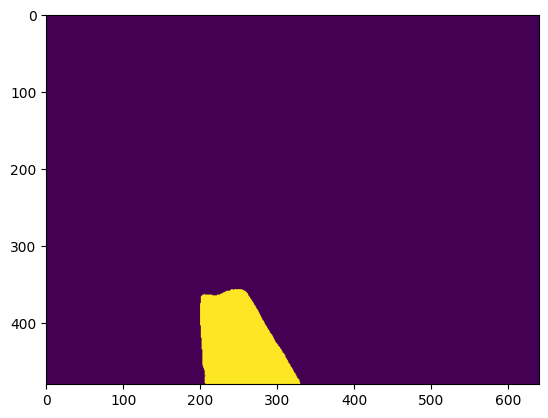

In [71]:
plt.imshow(all_tracks[0].masks[20])

In [73]:
masked_images = visualize_tracks(images,all_tracks,'mark')

In [74]:
from pathlib import Path
out_dir = Path('/home/kondrashov_k/mipt/lab/vggt_results/outputs/2')
track_out_dir = Path('/home/kondrashov_k/mipt/lab/vggt_results/track_outputs/2')
out_meta_dir = Path('/home/kondrashov_k/mipt/lab/vggt_results/meta_outputs/2')
out_filtered_dir = Path('/home/kondrashov_k/mipt/lab/vggt_results/filtered_outputs/2')
out_point_dir = Path('/home/kondrashov_k/mipt/lab/vggt_results/point_outputs/2')
out_meta_dir.mkdir(parents=True, exist_ok=True)
out_point_dir.mkdir(parents=True, exist_ok=True)
out_filtered_dir.mkdir(parents=True, exist_ok=True)
out_dir.mkdir(parents=True, exist_ok=True)

In [75]:
for i in range(len(masked_images)):
    cv2.imwrite(out_dir / f"{i}.png", masked_images[i])

In [76]:
import shutil
shutil.rmtree(track_out_dir, ignore_errors=True)
track_out_dir.mkdir(parents=True, exist_ok=True)
for i in tracks.keys():
    np.savez(track_out_dir / f"{i}.npz", tracks[i],pickle=True)

In [77]:
import json

track_names = {int(idx):{'cls':t['cls']} for idx, t in tracks.items()}
with open(out_meta_dir / 'track_names.json', 'w') as f:
    json.dump(track_names, f, indent=4)


In [78]:
for i, mask in enumerate(points_per_frame_masks):
    np.save(out_filtered_dir / f"{i}_filtered.npy", mask)

In [79]:
for i, points in enumerate(points_per_frame):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    o3d.io.write_point_cloud(str(out_point_dir / f"{i}.ply"), pcd)

In [80]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def show_pointcloud_in_notebook(pcd, max_points=100000, downsample_step=None):
    """Визуализация одного Open3D PointCloud в Jupyter через Plotly (как в lab/notes/da3.ipynb)."""
    pts = np.asarray(pcd.points)
    clr = np.asarray(pcd.colors) if pcd.has_colors() else np.ones((len(pts), 3)) * 0.7
    n = len(pts)
    if downsample_step is None:
        downsample_step = max(1, n // max_points)
    step = downsample_step
    pts, clr = pts[::step], clr[::step]
    rgb_str = np.array([f"rgb({r*255:.0f},{g*255:.0f},{b*255:.0f})" for r, g, b in clr])
    fig = go.Figure(
        data=[
            go.Scatter3d(
                x=pts[:, 0],
                y=pts[:, 1],
                z=pts[:, 2],
                mode="markers",
                marker=dict(size=1.5, color=rgb_str),
            )
        ]
    )
    fig.update_layout(
        scene=dict(
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            zaxis=dict(visible=False),
            bgcolor="rgb(20,20,20)",
        ),
        margin=dict(l=0, r=0, t=0, b=0),
        height=500,
    )
    return fig


def _subsample_points(pts, max_n):
    if len(pts) <= max_n:
        return pts
    idx = np.random.choice(len(pts), max_n, replace=False)
    return pts[idx]


def track_point_clouds_at_frame(
    frame_idx, all_tracks, points_per_frame, points_per_frame_masks, h, w
):
    """3D-точки по каждому треку на кадре frame_idx (тот же pipeline, что при tracker.update)."""
    clouds = []
    for track in all_tracks:
        if frame_idx not in track.masks:
            continue
        pts = get_obj_point_cloud(
            points_per_frame[frame_idx],
            points_per_frame_masks[frame_idx],
            track.masks[frame_idx],
            h,
            w,
        )
        if len(pts) == 0:
            continue
        clouds.append((track.id, pts))
    return clouds


def tracks_to_merged_open3d_pcd(
    frame_idx,
    all_tracks,
    points_per_frame,
    points_per_frame_masks,
    h,
    w,
    track_colors=None,
):
    """Одно o3d.geometry.PointCloud: все треки на кадре, цвет закреплён за id трека."""
    if track_colors is None:
        track_colors = distinctipy.get_colors(len(all_tracks))
    id_to_j = {t.id: j for j, t in enumerate(all_tracks)}
    clouds = track_point_clouds_at_frame(
        frame_idx, all_tracks, points_per_frame, points_per_frame_masks, h, w
    )
    merged = o3d.geometry.PointCloud()
    if not clouds:
        return merged
    parts = []
    cols = []
    for tid, pts in clouds:
        j = id_to_j.get(tid, 0)
        c = np.asarray(track_colors[j], dtype=np.float64)
        parts.append(pts)
        cols.append(np.tile(c, (len(pts), 1)))
    all_pts = np.vstack(parts)
    all_cols = np.vstack(cols)
    merged.points = o3d.utility.Vector3dVector(all_pts)
    merged.colors = o3d.utility.Vector3dVector(all_cols)
    return merged


def show_tracks_pointclouds_at_frame(
    frame_idx,
    all_tracks,
    points_per_frame,
    points_per_frame_masks,
    h,
    w,
    track_colors=None,
    max_points_per_track=20000,
    title=None,
):
    """Один момент времени: треки разными цветами (Plotly)."""
    if track_colors is None:
        track_colors = distinctipy.get_colors(len(all_tracks))
    id_to_j = {t.id: j for j, t in enumerate(all_tracks)}
    fig = go.Figure()
    clouds = track_point_clouds_at_frame(
        frame_idx, all_tracks, points_per_frame, points_per_frame_masks, h, w
    )
    for tid, pts in clouds:
        j = id_to_j.get(tid, 0)
        c = track_colors[j]
        pts_ds = _subsample_points(pts, max_points_per_track)
        rgb_str = f"rgb({c[0]*255:.0f},{c[1]*255:.0f},{c[2]*255:.0f})"
        fig.add_trace(
            go.Scatter3d(
                x=pts_ds[:, 0],
                y=pts_ds[:, 1],
                z=pts_ds[:, 2],
                mode="markers",
                marker=dict(size=2, color=rgb_str),
                name=f"track {tid}",
            )
        )
    fig.update_layout(
        title=title if title is not None else f"Кадр {frame_idx}",
        scene=dict(
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            zaxis=dict(visible=False),
            bgcolor="rgb(20,20,20)",
        ),
        margin=dict(l=0, r=0, t=50, b=0),
        height=560,
    )
    return fig


def show_tracks_pointclouds_at_frames(
    frame_indices,
    all_tracks,
    points_per_frame,
    points_per_frame_masks,
    h,
    w,
    track_colors=None,
    max_points_per_track=15000,
):
    """Несколько моментов времени: подряд в subplot (одинаковые цвета для одного track id)."""
    if track_colors is None:
        track_colors = distinctipy.get_colors(len(all_tracks))
    cols = len(frame_indices)
    fig = make_subplots(
        rows=1,
        cols=cols,
        specs=[[{"type": "scatter3d"}] * cols],
        subplot_titles=[f"Кадр {fi}" for fi in frame_indices],
        horizontal_spacing=0.03,
    )
    id_to_j = {t.id: j for j, t in enumerate(all_tracks)}
    for col, frame_idx in enumerate(frame_indices, start=1):
        clouds = track_point_clouds_at_frame(
            frame_idx, all_tracks, points_per_frame, points_per_frame_masks, h, w
        )
        for tid, pts in clouds:
            j = id_to_j.get(tid, 0)
            c = track_colors[j]
            pts_ds = _subsample_points(pts, max_points_per_track)
            rgb_str = f"rgb({c[0]*255:.0f},{c[1]*255:.0f},{c[2]*255:.0f})"
            fig.add_trace(
                go.Scatter3d(
                    x=pts_ds[:, 0],
                    y=pts_ds[:, 1],
                    z=pts_ds[:, 2],
                    mode="markers",
                    marker=dict(size=2, color=rgb_str),
                    name=f"track {tid}",
                    legendgroup=str(tid),
                    showlegend=(col == 1),
                ),
                row=1,
                col=col,
            )
    fig.update_layout(height=520, margin=dict(l=0, r=0, t=50, b=0))
    fig.update_scenes(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        bgcolor="rgb(20,20,20)",
    )
    return fig


# Пример (после all_tracks, points_per_frame, h, w):
# mid = len(images) // 2
# fig_3d = show_tracks_pointclouds_at_frames(
#     [0, mid, len(images) - 1], all_tracks, points_per_frame, points_per_frame_masks, h, w
# )
# fig_3d.show()
# pcd_tracks = tracks_to_merged_open3d_pcd(mid, all_tracks, points_per_frame, points_per_frame_masks, h, w)
# o3d.visualization.draw_geometries([pcd_tracks])


In [82]:
import json
import pickle
from pathlib import Path

import numpy as np

# Данные для lab/scripts/tracker_layers_rerun.py (камера, сцена, треки, combined ply)
RERUN_EXPORT_DIR = out_point_dir / "rerun_export"
RERUN_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

tracks_serial = []
for t in all_tracks:
    tid = int(t.id)
    voxels_by_frame = {
        int(frame_idx): np.asarray(pts, dtype=np.float32)
        for frame_idx, pts in track_voxels_history.get(tid, {}).items()
    }
    tracks_serial.append(
        {
            "id": tid,
            "masks": {int(k): v for k, v in t.masks.items()},
            "voxels_by_frame": voxels_by_frame,
        }
    )
with open(RERUN_EXPORT_DIR / "tracks.pkl", "wb") as f:
    pickle.dump(tracks_serial, f, protocol=pickle.HIGHEST_PROTOCOL)

np.save(RERUN_EXPORT_DIR / "extrinsics.npy", np.stack(extrinsics, axis=0))

with open(RERUN_EXPORT_DIR / "points_per_frame.pkl", "wb") as f:
    pickle.dump(points_per_frame, f, protocol=pickle.HIGHEST_PROTOCOL)

with open(RERUN_EXPORT_DIR / "points_per_frame_masks.pkl", "wb") as f:
    pickle.dump(points_per_frame_masks, f, protocol=pickle.HIGHEST_PROTOCOL)

track_colors = distinctipy.get_colors(len(all_tracks))
np.save(RERUN_EXPORT_DIR / "track_colors.npy", np.array(track_colors))

config = {
    "depth_dir": depth_dir,
    "n_frames": len(images),
    "fps": 5.0,
    "scene_sub": 2,
    "track_sub": 1,
    "track_voxels_sub": 1,
    "track_voxels_radius": 0.004,
    "combined_sub": 2,
    "combined_alpha": 0.35,
    "combined_pcd_paths": [
        str(Path(res_dir) / "pcd" / "combined_pcd.ply"),
        str(Path("/home/kondrashov_k/mipt/lab/pcd/combined_pcd.ply")),
    ],
}
with open(RERUN_EXPORT_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print("Saved rerun export to", RERUN_EXPORT_DIR)


Saved rerun export to /home/kondrashov_k/mipt/lab/vggt_results/point_outputs/2/rerun_export


In [ ]:
import subprocess
import sys
from pathlib import Path

# После ячейки сохранения export; нужны: rerun-sdk, те же пути к depth_dir на диске
SCRIPT = Path("../scripts/tracker_layers_rerun.py")
RERUN_EXPORT_DIR = out_point_dir / "rerun_export"
TRACK_RRD_OUT = out_point_dir / "tracker_layers.rrd"
RUNPY_RRD_OUT = out_point_dir / "runpy_layers.rrd"
cmd = [
    sys.executable,
    str(SCRIPT),
    "--export-dir",
    str(RERUN_EXPORT_DIR),
    "--save",
    str(TRACK_RRD_OUT)
]
print("Running:", " ".join(cmd))
subprocess.check_call(cmd)
print("Wrote", TRACK_RRD_OUT)


Running: /home/kondrashov_k/miniconda3/envs/main/bin/python /home/kondrashov_k/mipt/lab/scripts/tracker_layers_rerun.py --export-dir /home/kondrashov_k/mipt/lab/vggt_results/point_outputs/2/rerun_export --save /home/kondrashov_k/mipt/lab/vggt_results/point_outputs/2/tracker_layers.rrd
Logged combined PCD: /home/kondrashov_k/mipt/lab/tmp/2/pcd/combined_pcd.ply (2841902 pts)
Saved: /home/kondrashov_k/mipt/lab/vggt_results/point_outputs/2/tracker_layers.rrd
Wrote /home/kondrashov_k/mipt/lab/vggt_results/point_outputs/2/tracker_layers.rrd


In [84]:
# Экспорт в формат, который потребляет адаптер runpy_rerun_adapter.py
# (далее адаптер прокидывает данные в yolo_sgg/rerun_utils.RerunVisualizer без изменения run.py)
import json
import pickle
from pathlib import Path

import numpy as np

RUNPY_EXPORT_DIR = out_point_dir / "runpy_export"
RUNPY_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Берем intrinsics для RerunVisualizer из первого depth npz
intr0 = np.load(depth_dir + "frame_0.npz")["intrinsics"].astype(np.float32)
fx = float(intr0[0, 0])
fy = float(intr0[1, 1])
cx = float(intr0[0, 2])
cy = float(intr0[1, 2])
img_h, img_w = images[0].shape[:2]


def _cls_at_frame(track, frame_idx: int):
    if frame_idx in track.cls:
        return track.cls[frame_idx]
    prev = [k for k in track.cls.keys() if k <= frame_idx]
    if not prev:
        return None
    return track.cls[max(prev)]


n_frames = len(images)
objects_by_frame = []
masks_clean_by_frame = []
track_ids_by_frame = []
class_names_by_frame = []

for i in range(n_frames):
    frame_objs = []
    frame_masks = []
    frame_track_ids = []
    frame_class_names = []

    for t in all_tracks:
        tid = int(t.id)
        pts = track_voxels_history.get(tid, {}).get(int(i))
        if pts is None:
            continue

        pts = np.asarray(pts, dtype=np.float32)
        if len(pts) == 0:
            continue

        pmin = pts.min(axis=0).astype(np.float32)
        pmax = pts.max(axis=0).astype(np.float32)

        cls_val = _cls_at_frame(t, i)
        cls_name = None if cls_val is None else str(cls_val)

        frame_objs.append(
            {
                "global_id": tid,
                "points": pts,
                "class_name": cls_name,
                "bbox_3d": {
                    "aabb": {
                        "min": pmin.tolist(),
                        "max": pmax.tolist(),
                    }
                },
                "visible_current_frame": True,
                "observation_count": int(sum(1 for k in t.masks.keys() if k <= i)),
            }
        )

        if i in t.masks:
            frame_masks.append(t.masks[i])
            frame_track_ids.append(tid)
            frame_class_names.append(cls_name)

    objects_by_frame.append(frame_objs)
    masks_clean_by_frame.append(frame_masks)
    track_ids_by_frame.append(np.array(frame_track_ids, dtype=np.int32))
    class_names_by_frame.append(frame_class_names)

with open(RUNPY_EXPORT_DIR / "runpy_objects.pkl", "wb") as f:
    pickle.dump(objects_by_frame, f, protocol=pickle.HIGHEST_PROTOCOL)

with open(RUNPY_EXPORT_DIR / "runpy_masks_clean.pkl", "wb") as f:
    pickle.dump(masks_clean_by_frame, f, protocol=pickle.HIGHEST_PROTOCOL)

with open(RUNPY_EXPORT_DIR / "runpy_track_ids.pkl", "wb") as f:
    pickle.dump(track_ids_by_frame, f, protocol=pickle.HIGHEST_PROTOCOL)

with open(RUNPY_EXPORT_DIR / "runpy_class_names.pkl", "wb") as f:
    pickle.dump(class_names_by_frame, f, protocol=pickle.HIGHEST_PROTOCOL)

np.save(RUNPY_EXPORT_DIR / "runpy_T_w_c.npy", np.stack(extrinsics, axis=0).astype(np.float32))

cfg = {
    "recording_id": "tracker_runpy_adapter",
    "img_w": int(img_w),
    "img_h": int(img_h),
    "fx": fx,
    "fy": fy,
    "cx": cx,
    "cy": cy,
    "rgb_paths": image_paths,
    "vis_edges": False,
}
with open(RUNPY_EXPORT_DIR / "runpy_export_config.json", "w", encoding="utf-8") as f:
    json.dump(cfg, f, indent=2, ensure_ascii=False)

# Опционально: можно добавить runpy_graph_edges.json со списком ребер {src, dst, label}
print("Saved run.py-compatible export to", RUNPY_EXPORT_DIR)

Saved run.py-compatible export to /home/kondrashov_k/mipt/lab/vggt_results/point_outputs/2/runpy_export


In [ ]:
# Запуск адаптера (откроет Rerun UI через RerunVisualizer)
import subprocess
import sys
from pathlib import Path

SCRIPT = Path("../scripts/runpy_rerun_adapter.py")
RUNPY_EXPORT_DIR = out_point_dir / "runpy_export"

cmd = [
    sys.executable,
    str(SCRIPT),
    "--export-dir",
    str(RUNPY_EXPORT_DIR),
    "--no-spawn",
    "--save",
    str(RUNPY_RRD_OUT)
]
print("Running:", " ".join(cmd))
subprocess.check_call(cmd)

Running: /home/kondrashov_k/miniconda3/envs/main/bin/python /home/kondrashov_k/mipt/lab/pipeline/sg/scripts/runpy_rerun_adapter.py --export-dir /home/kondrashov_k/mipt/lab/vggt_results/point_outputs/2/runpy_export


Error: winit EventLoopError: os error at /usr/local/cargo/registry/src/index.crates.io-1949cf8c6b5b557f/winit-0.30.12/src/platform_impl/linux/mod.rs:765: neither WAYLAND_DISPLAY nor WAYLAND_SOCKET nor DISPLAY is set.
 12%|█▏        | 33/271 [00:00<00:02, 81.07it/s][2026-03-24T13:06:04Z WARN  re_quota_channel::sync] batcher_output: Sender has been blocked for over 5 seconds waiting for space in channel
[2026-03-24T13:06:04Z WARN  re_quota_channel::sync] batcher_input: Sender has been blocked for over 5 seconds waiting for space in channel
 12%|█▏        | 33/271 [00:20<00:02, 81.07it/s]

KeyboardInterrupt: 